In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv(r"C:\Users\malik\Desktop\ML_Revise\05_Linear_reg\data\Walmart.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [147]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [148]:
df.describe()


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [149]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   str    
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 402.3 KB


In [150]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [151]:
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['week'] = df['Date'].dt.isocalendar().week

In [152]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,year,month,week
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9


In [153]:
df.ffill()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,year,month,week
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9
...,...,...,...,...,...,...,...,...,...,...,...
6430,45,2012-09-28,713173.95,0,64.88,3.997,192.013558,8.684,2012,9,39
6431,45,2012-10-05,733455.07,0,64.89,3.985,192.170412,8.667,2012,10,40
6432,45,2012-10-12,734464.36,0,54.47,4.000,192.327265,8.667,2012,10,41
6433,45,2012-10-19,718125.53,0,56.47,3.969,192.330854,8.667,2012,10,42


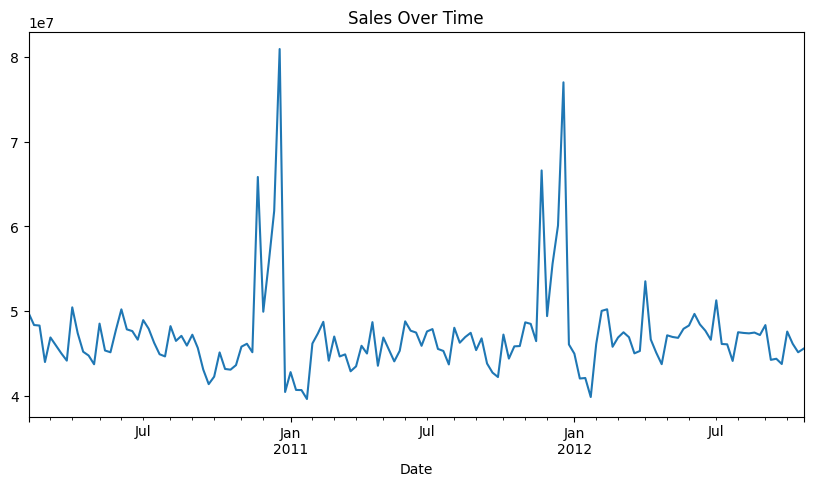

In [154]:
plt.figure(figsize=(10,5))
df.groupby('Date')['Weekly_Sales'].sum().plot()
plt.title("Sales Over Time")
plt.show()

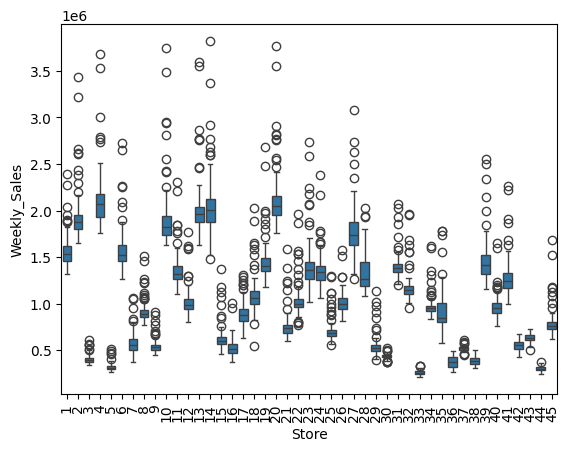

In [155]:
sns.boxplot(x='Store', y='Weekly_Sales', data=df)
plt.xticks(rotation=90)
plt.show()

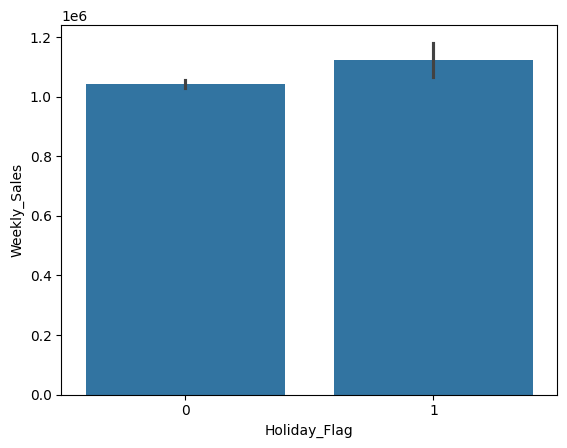

In [156]:
sns.barplot(x='Holiday_Flag', y='Weekly_Sales', data=df)
plt.show()

In [157]:
df = df.sort_values(by=['Store','Date'])

df['lag_1'] = df.groupby('Store')['Weekly_Sales'].shift(1)
df['lag_2'] = df.groupby('Store')['Weekly_Sales'].shift(2)
df['lag_3'] = df.groupby('Store')['Weekly_Sales'].shift(3)
df['lag_4'] = df.groupby('Store')['Weekly_Sales'].shift(4)

df['rolling_mean'] = df.groupby('Store')['Weekly_Sales'].transform(lambda x: x.rolling(4).mean())
df['rolling_std'] = df.groupby('Store')['Weekly_Sales'].transform(lambda x: x.rolling(4).std())

df['price_cpi'] = df['Fuel_Price'] * df['CPI']
df['unemp_holiday'] = df['Unemployment'] * df['Holiday_Flag']

df.dropna(inplace=True)

In [158]:
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,year,month,week,lag_1,lag_2,lag_3,lag_4,rolling_mean,rolling_std,price_cpi,unemp_holiday
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9,1409727.59,1611968.17,1641957.44,1643690.90,1.554615e+06,103135.002548,554.794125,0.0
5,1,2010-03-12,1439541.59,0,57.79,2.667,211.380643,8.106,2010,3,10,1554806.68,1409727.59,1611968.17,1641957.44,1.504011e+06,95360.050839,563.752175,0.0
6,1,2010-03-19,1472515.79,0,54.58,2.720,211.215635,8.106,2010,3,11,1439541.59,1554806.68,1409727.59,1611968.17,1.469148e+06,62599.457150,574.506527,0.0
7,1,2010-03-26,1404429.92,0,51.45,2.732,211.018042,8.106,2010,3,12,1472515.79,1439541.59,1554806.68,1409727.59,1.467823e+06,64308.381016,576.501292,0.0
8,1,2010-04-02,1594968.28,0,62.27,2.719,210.820450,7.808,2010,4,13,1404429.92,1472515.79,1439541.59,1554806.68,1.477864e+06,82871.762296,573.220803,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6430,45,2012-09-28,713173.95,0,64.88,3.997,192.013558,8.684,2012,9,39,723086.20,702238.27,766512.66,734297.87,7.262528e+05,28158.111035,767.478190,0.0
6431,45,2012-10-05,733455.07,0,64.89,3.985,192.170412,8.667,2012,10,40,713173.95,723086.20,702238.27,766512.66,7.179884e+05,13372.247001,765.799090,0.0
6432,45,2012-10-12,734464.36,0,54.47,4.000,192.327265,8.667,2012,10,41,733455.07,713173.95,723086.20,702238.27,7.260449e+05,10003.552464,769.309062,0.0
6433,45,2012-10-19,718125.53,0,56.47,3.969,192.330854,8.667,2012,10,42,734464.36,733455.07,713173.95,723086.20,7.248047e+05,10770.694653,763.361160,0.0


In [159]:
df = pd.get_dummies(df, columns=['Store'], drop_first=True)

In [160]:
df.dropna(inplace=True)

In [161]:
train = df[df['Date'] < '2012-01-01']
test = df[df['Date'] >= '2012-01-01']

In [162]:
features = [
    'Fuel_Price','CPI','Unemployment',
    'Holiday_Flag','year','month','week',
    'lag_1','lag_2','lag_3','lag_4',
    'rolling_mean','rolling_std',
    'price_cpi','unemp_holiday'
] + [col for col in df.columns if 'Store_' in col]

X_train = train[features]
y_train = train['Weekly_Sales']

X_test = test[features]
y_test = test['Weekly_Sales']
feature_names = X_train.columns
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [163]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

model.fit(X_train, y_train_log)

pred_log = model.predict(X_test)
y_pred = np.expm1(pred_log)

In [164]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 27738.14605414909
MSE: 1489870840.742241
RMSE: 38598.845070056705
R2 Score: 0.9948241073632559


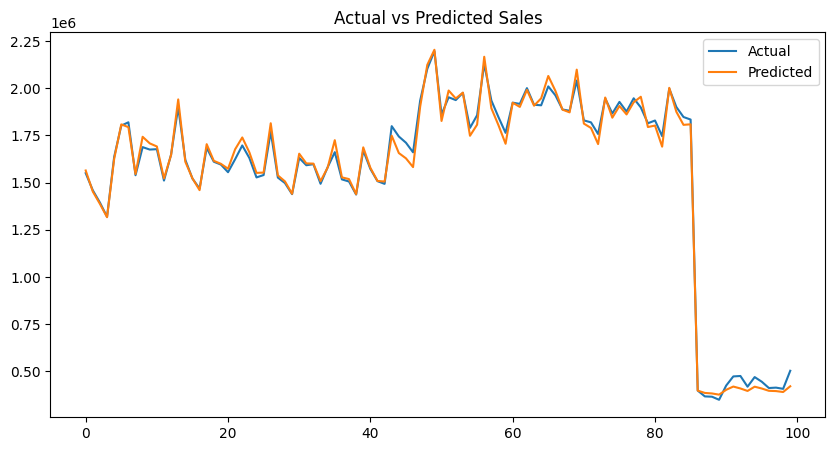

In [165]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label="Actual")
plt.plot(y_pred[:100], label="Predicted")
plt.title("Actual vs Predicted Sales")
plt.legend()
plt.show()

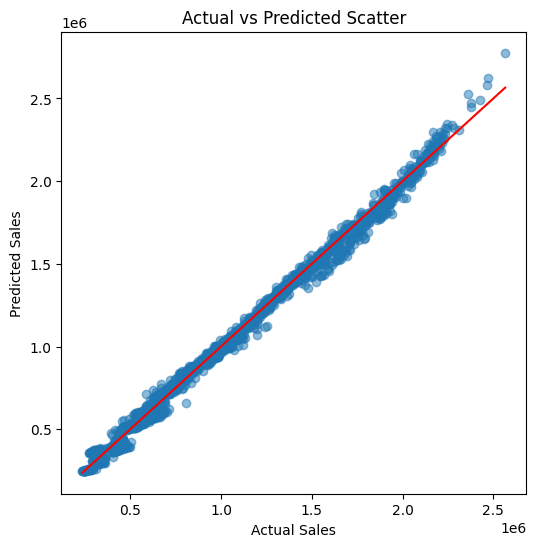

In [166]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Scatter")

# perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()

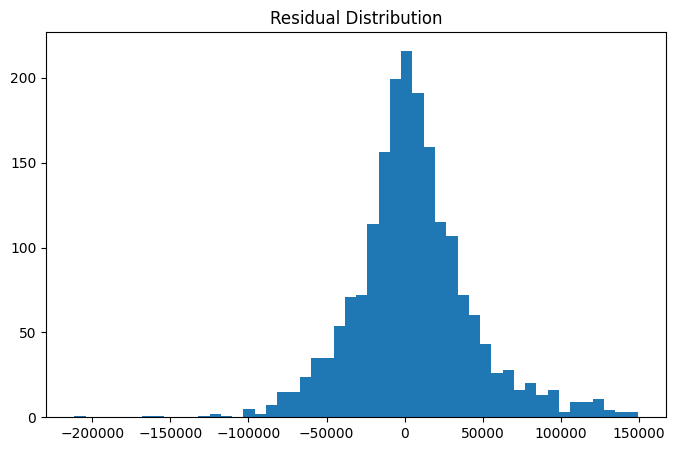

In [167]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.hist(residuals, bins=50)
plt.title("Residual Distribution")
plt.show()

In [168]:


# then scale
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": model.coef_
})

print(coefficients.sort_values(by="Coefficient", ascending=False))

          Feature  Coefficient
11   rolling_mean     1.433399
1             CPI     0.148873
5           month     0.091169
36       Store_23     0.042804
32       Store_19     0.037854
37       Store_24     0.037838
53       Store_40     0.035096
31       Store_18     0.031776
39       Store_26     0.031305
41       Store_28     0.031244
40       Store_27     0.030476
26       Store_13     0.030435
30       Store_17     0.030020
23       Store_10     0.030014
35       Store_22     0.029967
17        Store_4     0.029579
47       Store_34     0.028404
48       Store_35     0.023656
2    Unemployment     0.023277
25       Store_12     0.023192
0      Fuel_Price     0.012460
54       Store_41     0.010989
3    Holiday_Flag     0.007383
45       Store_32     0.006705
28       Store_15     0.002834
44       Store_31     0.000422
19        Store_6     0.000164
52       Store_39    -0.000045
4            year    -0.000110
24       Store_11    -0.000428
27       Store_14    -0.001853
14  unem

In [169]:
sample = X_test[0].reshape(1, -1)

pred_log = model.predict(sample)
prediction = np.expm1(pred_log)

print("Predicted Sales:", prediction[0])
print("Actual Sales:", y_test.iloc[0])

Predicted Sales: 1564587.2628298737
Actual Sales: 1550369.92


In [170]:
import joblib

joblib.dump(model, "linear_regression_sales.pkl")

['linear_regression_sales.pkl']

In [171]:
print("Model Performance Summary")
print("------------------------")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.4f}")

Model Performance Summary
------------------------
MAE  : 27738.15
RMSE : 38598.85
R2   : 0.9948


will SWITCH MODEL in FUTURE (BIGGEST BOOST)

Linear Regression is too simple...........